In [12]:
import numpy as np

from pyaml.accelerator import Accelerator
from pyaml.common.constants import Action

## Facility configuration

Edit the `CONFIG_FILE` variable below to select the facility. The rest of the notebook runs unchanged.

| Facility | Config file | Control system | Virtual twin |
|----------|-------------|----------------|--------------|
| SOLEIL II | `config/soleil_ii/p.yaml` | TANGO (`tango-pyaml`) | Apptainer container |
| BESSY2 | `config/bessy2/bessy2.yaml` | EPICS (`pyaml-cs-oa`) | Apptainer container |
| ESRF EBS | `config/esrf/esrf.yaml` | TANGO (`tango-pyaml`) | Apptainer container |

See `README.md` for installation and virtual accelerator startup instructions.

In [13]:
# ── Facility configuration ──────────────────────────────────────────────────
# Uncomment the facility you want to use:

# CONFIG_FILE = "config/soleil_ii/p.yaml"
# CONFIG_FILE = "config/bessy2/bessy2.yaml"
CONFIG_FILE = "config/esrf/esrf.yaml"
# ────────────────────────────────────────────────────────────────────────────

sr = Accelerator.load(CONFIG_FILE)
sr  # string representation

14 Aug 2026, 13:41:08 | WARNING | PyAML Tango control system binding (0.4.0) initialized with name 'live' and TANGO_HOST=ebs-simu-3:10000
14 Aug 2026, 13:41:10 | WARNING | /home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/esrf/chroma_resp.json: file not found
14 Aug 2026, 13:41:10 | WARNING | Loading /home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/esrf/orm.json failed /home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/esrf/orm.json: file not found


Accelerator(facility='ESRF', machine='sr', description=None, live=TangoControlSystem(name='live', tango_host='ebs-simu-3:10000', catalog=<tango.pyaml.static_catalog.StaticCatalog object at 0x783993c644d0>, debug_level=None, lazy_devices=True, timeout_ms=3000), design=Simulator(name='design', lattice='/home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/esrf/sr/lattices/ebs.mat', mat_key=None, linker=None, description=None), yellow_pages=Controls:
    live
    .

Simulators:
    design
    .

Arrays:
    BPM                   (pyaml.arrays.bpm_array)                size=320
    HCorr                 (pyaml.arrays.magnet_array)             size=288
    VCorr                 (pyaml.arrays.magnet_array)             size=288
    Skews                 (pyaml.arrays.magnet_array)             size=288
    Sext                  (pyaml.arrays.magnet_array)             size=180
    QForTune              (pyaml.arrays.magnet_array)             size=124
    .

Tools:
    BB

### Virtual accelerator setup

For **live** control mode you need a running control system or emulator. If you want to skip this, run the notebook in **design** mode only.

**SOLEIL II / ESRF (TANGO)**
```
apptainer pull virtual-accelerator.sif oras://gitlab-registry.synchrotron-soleil.fr/software-control-system/containers/apptainer/virtual-accelerator:latest
apptainer run virtual-accelerator.sif
```

**BESSY2 (EPICS)**
```
apptainer run oras://registry.hzdr.de/digital-twins-for-accelerators/containers/pyat-softioc-digital-twin:default-v0-5-1-bessy.2711893
```

> **Note for BESSY2 live mode:** the PV prefix in `config/bessy2/bessy2.yaml` must match your virtual accelerator instance. Edit the `prefix:` field under `controls:`.

### Control mode choice

- **`sr.design`** — runs pyAT locally, no control system needed. Set `wait_time = 0.0`.
- **`sr.live`** — connects to the real machine or virtual twin. Set `wait_time` to allow readback settling (typically 1.5–2 s).

In [14]:
SR = sr.design
# SR = sr.live

wait_time = 0.0 if SR == sr.design else 2.0
SR  # string representation

Simulator(name='design', lattice='/home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/esrf/sr/lattices/ebs.mat', mat_key=None, linker=None, description=None)

### Momentum compaction factor

The momentum compaction factor α_c is needed to convert RF frequency deviation to momentum deviation. It is computed from the lattice model (design mode).

In [15]:
sr.design.get_lattice().disable_6d()
alphac = sr.design.get_lattice().get_mcf()
sr.design.get_lattice().enable_6d()
print(f"Momentum compaction factor: αc = {alphac:.6e}")

Momentum compaction factor: αc = 8.623615e-05


### Chromaticity measurement

The chromaticity monitor is named `CHROMATICITY_MONITOR` in the configuration. The measurement sweeps the RF frequency and fits the resulting tune shift.

Parameters:
- `alphac` — momentum compaction factor (from lattice above)
- `fit_order` — polynomial fit order (2 = quadratic)
- `n_step` — number of RF frequency steps
- `sleep_between_meas` / `sleep_between_step` — settling times (set to `wait_time` for live mode)
- `do_plot=True` — show the tune vs. δp fit

In [16]:
def chroma_callback(action: int, cb_data: dict):
    if action == Action.MEASURE:
        print(f"Chromaticity: #{cb_data['step']} RF={cb_data['rf']:.2f} Hz, Tune={cb_data['tune']}")
    return True

Chromaticity: #0 RF=352372199.79 Hz, Tune=[0.15148296 0.33444759]
Chromaticity: #1 RF=352372184.59 Hz, Tune=[0.15569448 0.33720674]
Chromaticity: #2 RF=352372169.40 Hz, Tune=[0.15996911 0.34002636]
Chromaticity: #3 RF=352372154.21 Hz, Tune=[0.16430419 0.3429056 ]
Chromaticity: #4 RF=352372139.01 Hz, Tune=[0.16869704 0.34584364]


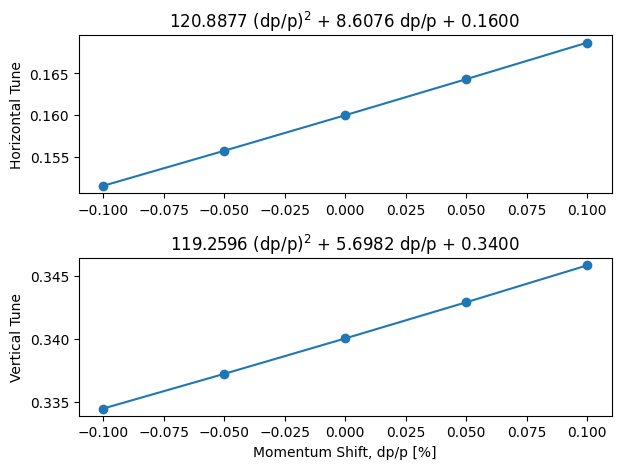

True

In [17]:
chroma_monitor = SR.get_chromaticity_monitor("CHROMATICITY_MONITOR")

chroma_monitor.measure(
    callback=chroma_callback,
    do_plot=True,
    alphac=alphac,
    fit_order=2,
    n_step=5,
    sleep_between_meas=wait_time,
    sleep_between_step=wait_time,
)

In [18]:
ksi = chroma_monitor.chromaticity.get()
print(f"Measured chromaticity: ξx = {ksi[0]:.3f}, ξy = {ksi[1]:.3f}")

Measured chromaticity: ξx = 8.608, ξy = 5.698
